**Step 1: Import Libraries**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load Dataset**

In [27]:
data = pd.read_csv("Mall_Customers.csv")

print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


**Step 3: Data Preprocessing**

In [28]:
# check null values
print(data.isnull().sum())

# encode Gender
data['Gender'] = data['Gender'].map({'Male':0, 'Female':1})

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**Step 4: Exploratory Data Analysis**

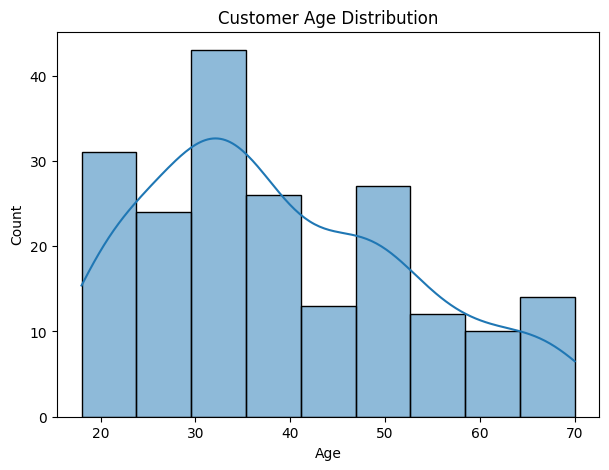

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

data = pd.read_csv("Mall_Customers.csv")

plt.figure(figsize=(7,5))

sns.histplot(
    data['Age'],
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")

plt.show()

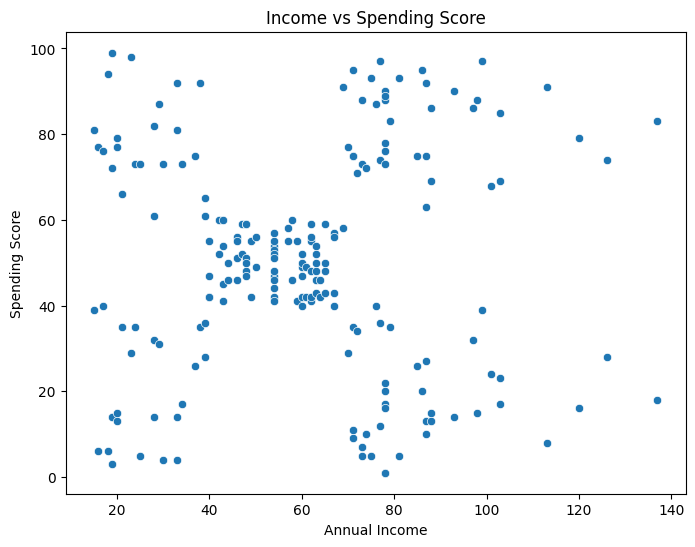

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data['Annual Income (k$)'],
    y=data['Spending Score (1-100)']
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

**Step 5: Feature Selection**

In [31]:
X = data[['Annual Income (k$)',
          'Spending Score (1-100)']]

**Step 6: Elbow Method**

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

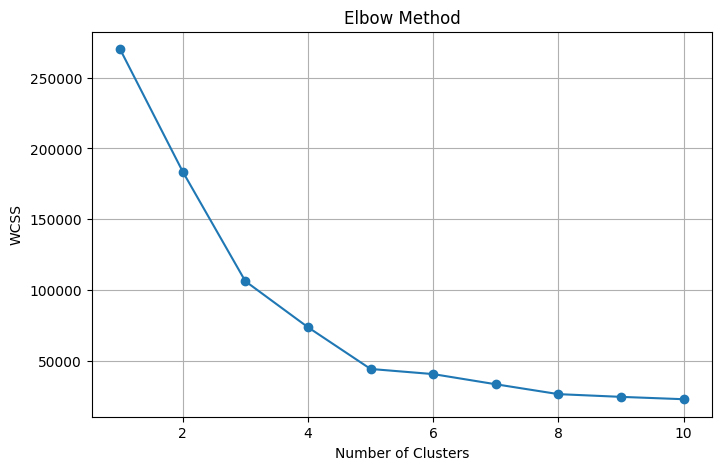

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

**Step 7: Apply K-Means Clustering**

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

data['Cluster'] = y_kmeans

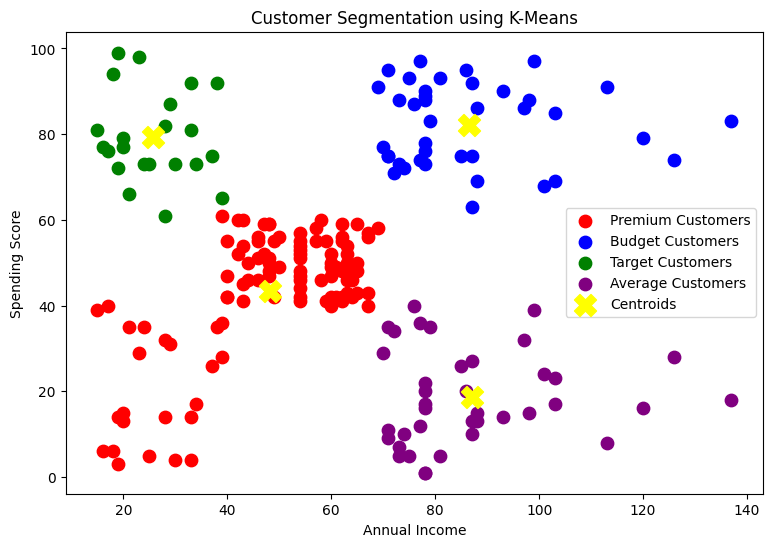

In [ ]:
plt.figure(figsize=(9,6))

colors = ['red', 'blue', 'green', 'purple']

cluster_names = [
    'Premium Customers',
    'Budget Customers',
    'Target Customers',
    'Average Customers'
]

for i in range(4):

    plt.scatter(
        X[y_kmeans == i]['Annual Income (k$)'],
        X[y_kmeans == i]['Spending Score (1-100)'],
        s=80,
        c=colors[i],
        label=cluster_names[i]
    )

# centroids
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=250,
    c='yellow',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.legend()

plt.show()

**Step 8: PCA Visualization**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

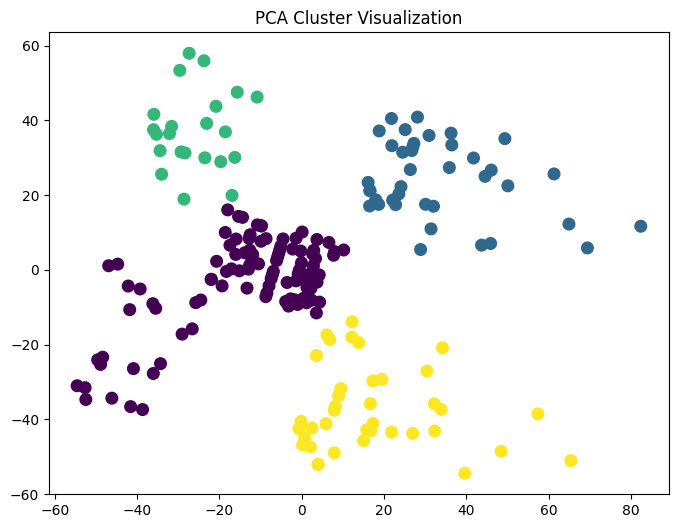

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_kmeans,
    s=70
)

plt.title("PCA Cluster Visualization")

plt.show()

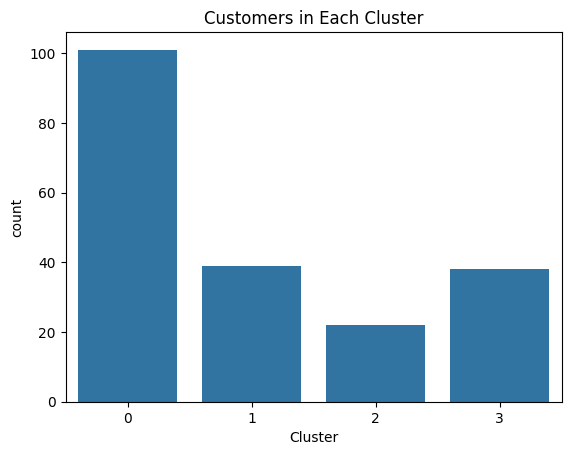

In [ ]:
sns.countplot(
    x='Cluster',
    data=data
)

plt.title("Customers in Each Cluster")

plt.show()

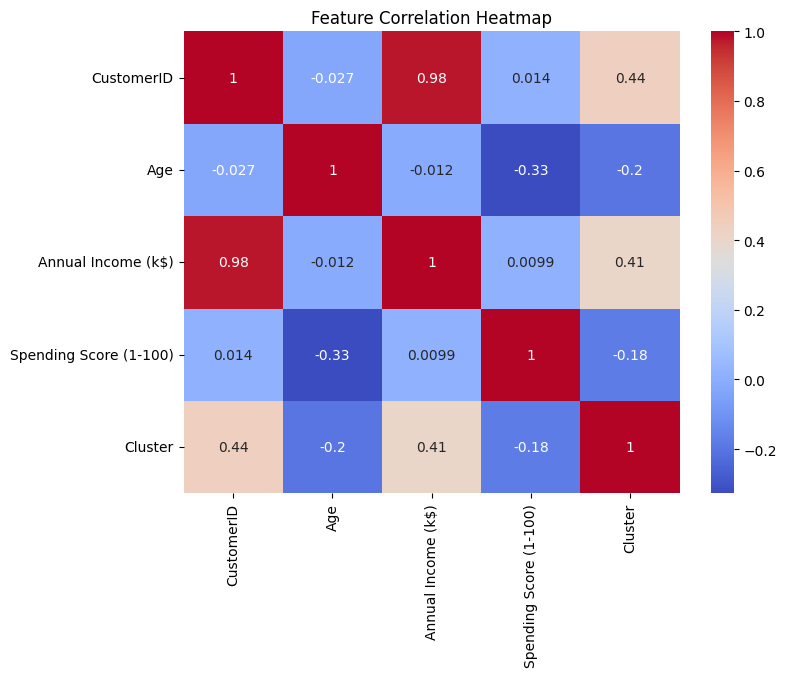

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()